AG3: Actividad Guiada 3

Nombre: Evelyn Sánchez Laureano

Link Colab: https://drive.google.com/file/d/1mt8TbVtMDJSTx_0WLjGzzinn5N_olWv2/view?usp=sharing

Link GitHub: eslaureano/Algoritmos_Optimizacion_MasterAI

#Carga de librerias

In [1]:
!pip install requests    #Hacer llamadas http a paginas de la red
!pip install tsplib95    #Modulo para las instancias del problema del TSP

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.4.1
    Uninstalling wrapt-2.4.1:
      Successfully uninstalled wrapt-2.4.1
  Attempting uninstall: tabulate
    Found existing installation: tabulate 0.9.0
    Uninstalling tabulate-0.9.0:
      Successfully uninstalled tabulate-0.9.0
  Attempting uninstall: networkx
    Found existing installation: networkx 3.6.1
    Uninstalling networkx-3.6.1:
      Successfully uninstalled networkx-3.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires networkx>=3.0, but you have networkx 2.8.8 which is incompatible.
bigframes 2.49.0 requires tabulate>=0.9, but you have tabulate 0.8.10 which is incompatible.
mapclassify 2.

#Carga de los datos del problema

In [2]:
import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#http://elib.zib.de/pub/mp-testdata/tsp/tsplib/
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
#urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/swiss42.tsp.gz", file + '.gz')
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#URL Alternativo
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file )

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)




('swiss42.tsp', <http.client.HTTPMessage at 0x78dac7c979d0>)

In [3]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [4]:
Aristas

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),



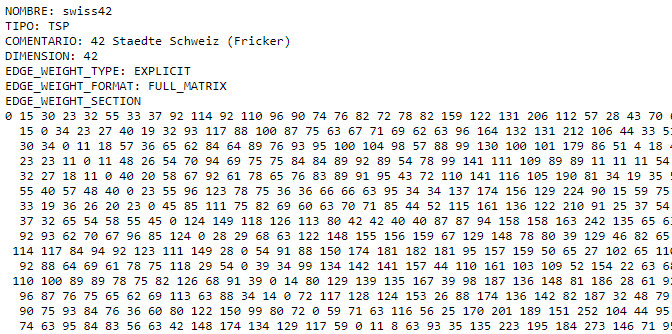

In [5]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(0, 1)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

15

In [6]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional


def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo solucion TSP")
    plt.show()

#Funcionas basicas


In [7]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)

distancia_total(sol_temporal, problem), sol_temporal

(4997,
 [0,
  39,
  10,
  19,
  32,
  35,
  2,
  14,
  18,
  27,
  34,
  21,
  9,
  8,
  24,
  26,
  20,
  11,
  23,
  15,
  22,
  4,
  29,
  41,
  25,
  17,
  1,
  31,
  30,
  5,
  36,
  3,
  13,
  6,
  28,
  40,
  37,
  12,
  33,
  16,
  7,
  38])

#BUSQUEDA ALEATORIA

Mejor solución: [0, 13, 32, 36, 33, 17, 1, 15, 37, 20, 35, 34, 7, 14, 39, 40, 24, 9, 4, 6, 28, 21, 23, 10, 3, 31, 25, 18, 30, 16, 2, 19, 27, 12, 11, 8, 22, 41, 38, 29, 5, 26]
Distancia     : 3631


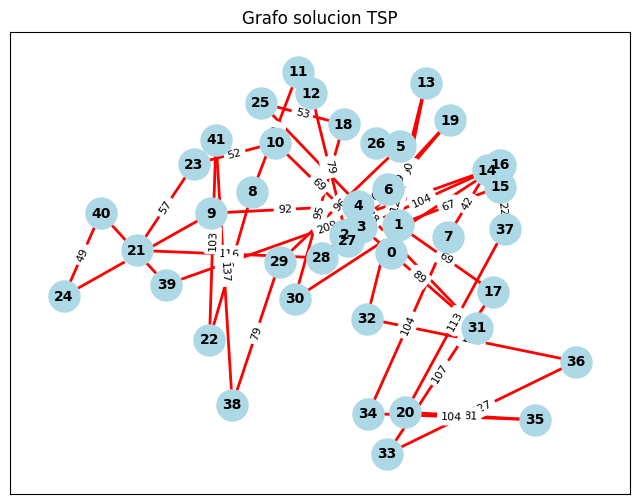

In [8]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 5000 iteraciones
solucion = busqueda_aleatoria(problem, 10000)

plot_tsp_solution(problem.edge_weights, solucion)

#BUSQUEDA LOCAL

In [9]:
###############################################################################
# BUSQUEDA LOCAL
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:

        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3631
Distancia Mejor Solucion Local: 3370


In [10]:
#Busqueda Local:
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  solucion_referencia = crear_solucion(Nodos)
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(problem )

En la iteracion  33 , la mejor solución encontrada es: [0, 30, 22, 39, 21, 29, 28, 4, 26, 13, 19, 5, 6, 3, 2, 27, 17, 37, 15, 16, 14, 7, 1, 18, 12, 11, 25, 10, 8, 41, 23, 9, 34, 33, 38, 24, 40, 32, 20, 35, 36, 31]
Distancia     : 1960


#SIMULATED ANNEALING


In [11]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

La mejor solución encontrada es [0, 1, 6, 13, 19, 16, 15, 14, 4, 27, 2, 32, 20, 33, 34, 38, 22, 39, 9, 23, 41, 11, 5, 26, 18, 12, 25, 10, 29, 30, 21, 24, 40, 8, 28, 3, 7, 37, 17, 36, 35, 31]
con una distancia total de 1754


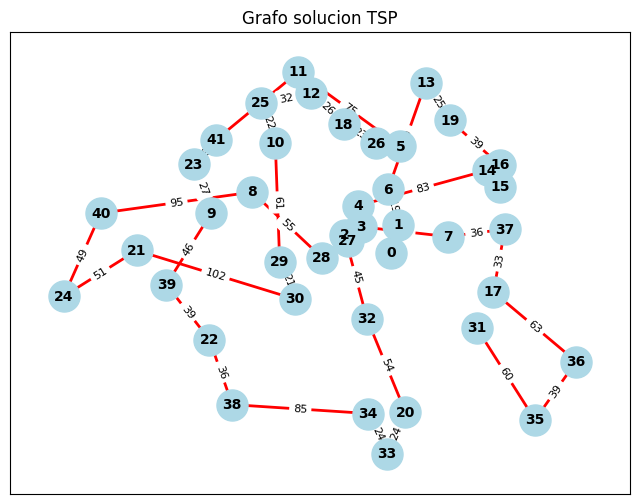

In [12]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

plot_tsp_solution(problem.edge_weights, sol)

# ACTIVIDADES EXTRA

## Extra 1: Mejora del algoritmo de búsqueda local

La búsqueda local de la plantilla se detiene en el primer mínimo local que encuentra, y ese mínimo depende de dos cosas: de la **solución inicial** de la que parte y del **operador de vecindad** que usa. Cada mejora ataca una de esas dos dependencias:

- **Multiarranque**: repetir la búsqueda local desde varias soluciones iniciales distintas y quedarse con el mejor mínimo local.
- **Búsqueda en entornos variables**: cuando el operador de vecindad ya no consigue mejorar, cambiar a otro operador distinto en lugar de parar.

### Multiarranque

Primero se reescribe la búsqueda local de la plantilla para que reciba la solución inicial y el generador de vecinas como parámetros (el algoritmo es el mismo). Así se puede lanzar tantas veces como se quiera desde puntos de partida distintos y reutilizarla en el resto de mejoras.

In [13]:
###############################################################################
# EXTRA 1 - BUSQUEDA LOCAL MULTIARRANQUE
###############################################################################

#Busqueda local de la plantilla, pero recibiendo como parametros la solucion inicial
#y el generador de vecinas para poder reutilizarla.
#Devuelve la solucion (minimo local) y su distancia
def busqueda_local_desde(solucion_inicial, problem, genera=genera_vecina):
  solucion_referencia = solucion_inicial
  mejor_distancia = distancia_total(solucion_referencia, problem)

  while(1):
    #Obtenemos la mejor vecina ...
    vecina = genera(solucion_referencia)

    #... y la evaluamos para ver si mejoramos
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local
    if distancia_vecina >= mejor_distancia:
      return solucion_referencia, mejor_distancia

    solucion_referencia = vecina
    mejor_distancia = distancia_vecina


#Multiarranque:
#  - Se repite la busqueda local desde N_arranques soluciones iniciales aleatorias
#  - Se devuelve el mejor de todos los minimos locales encontrados y la lista con la distancia de cada arranque
#  - El parametro busqueda permite elegir que busqueda local se lanza en cada arranque
def busqueda_local_multiarranque(problem, N_arranques, busqueda=busqueda_local_desde):
  mejor_solucion = []
  mejor_distancia = float('inf')
  distancias = []                       #Distancia obtenida en cada arranque

  for i in range(N_arranques):
    #Nuevo punto de partida aleatorio ...
    solucion_inicial = crear_solucion(Nodos)

    #... y busqueda local desde ese punto
    solucion_arranque, distancia_arranque = busqueda(solucion_inicial, problem)
    distancias.append(distancia_arranque)
    print("Arranque", i+1, "-> distancia:", distancia_arranque)

    #Compara con el mejor minimo local obtenido hasta ahora
    if distancia_arranque < mejor_distancia:
      mejor_solucion = solucion_arranque
      mejor_distancia = distancia_arranque

  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion, distancias


#Busqueda local multiarranque con 10 arranques
sol_multiarranque, distancias_multiarranque = busqueda_local_multiarranque(problem, 10)

Arranque 1 -> distancia: 1586
Arranque 2 -> distancia: 1689
Arranque 3 -> distancia: 1505
Arranque 4 -> distancia: 1780
Arranque 5 -> distancia: 1964
Arranque 6 -> distancia: 1841
Arranque 7 -> distancia: 1857
Arranque 8 -> distancia: 1774
Arranque 9 -> distancia: 1850
Arranque 10 -> distancia: 1725
Mejor solución: [0, 1, 4, 3, 27, 2, 28, 29, 30, 32, 20, 33, 34, 38, 22, 39, 24, 40, 21, 9, 23, 41, 25, 10, 8, 7, 17, 31, 35, 36, 37, 15, 16, 14, 19, 11, 12, 18, 26, 13, 5, 6]
Distancia     : 1505


### Búsqueda en entornos variables

Un mínimo local lo es respecto a un operador de vecindad concreto: una solución que ya no mejora intercambiando 2 nodos puede seguir mejorando con otro tipo de movimiento. Se definen tres entornos, todos con el mismo formato que `genera_vecina` (devuelven la mejor vecina de la solución recibida):

1. **Intercambio** de 2 nodos: el `genera_vecina` de la plantilla.
2. **Inversión** de un tramo (2-opt de aristas): se recorre al revés el tramo entre dos posiciones.
3. **Inserción**: se saca un nodo de su posición y se coloca en otra.

In [14]:
###############################################################################
# EXTRA 1 - BUSQUEDA EN ENTORNOS VARIABLES: nuevos operadores de vecindad
###############################################################################

#Entorno 2 - Inversion de un tramo (2-opt de aristas):
#  se recorre al reves el tramo entre las posiciones i y j. Solo cambian 2 aristas del recorrido
def genera_vecina_inversion(solucion):
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):
    for j in range(i+1, len(solucion)):

      #Nueva solucion con el tramo i..j invertido
      vecina = solucion[:i] + solucion[i:j+1][::-1] + solucion[j+1:]

      distancia_vecina = distancia_total(vecina, problem)
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#Entorno 3 - Insercion:
#  se saca el nodo de la posicion i y se inserta en la posicion j
def genera_vecina_insercion(solucion):
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)):
    resto = solucion[:i] + solucion[i+1:]             #Solucion sin el nodo de la posicion i
    for j in range(1,len(solucion)):
      if j != i:                                      #j = i devolveria la misma solucion

        #Nueva solucion con el nodo colocado en la posicion j
        vecina = resto[:j] + [solucion[i]] + resto[j:]

        distancia_vecina = distancia_total(vecina, problem)
        if distancia_vecina <= mejor_distancia:
          mejor_distancia = distancia_vecina
          mejor_solucion = vecina
  return mejor_solucion


#Probamos los nuevos entornos sobre la solucion de la busqueda aleatoria
print("Distancia Solucion Inicial     :" , distancia_total(solucion, problem))
print("Mejor vecina por intercambio   :" , distancia_total(genera_vecina(solucion), problem))
print("Mejor vecina por inversion     :" , distancia_total(genera_vecina_inversion(solucion), problem))
print("Mejor vecina por insercion     :" , distancia_total(genera_vecina_insercion(solucion), problem))

Distancia Solucion Inicial     : 3631
Mejor vecina por intercambio   : 3370
Mejor vecina por inversion     : 3436
Mejor vecina por insercion     : 3431


Con esos entornos se aplica la variante de descenso de la búsqueda en entornos variables (VND, *Variable Neighborhood Descent*):

- Se busca la mejor vecina en el entorno actual.
- Si mejora, nos movemos a ella y se vuelve al primer entorno.
- Si no mejora, se pasa al siguiente entorno.
- Se termina cuando ningún entorno consigue mejorar: la solución es mínimo local para los tres a la vez.

Como el primer entorno es el de la plantilla, partiendo de la misma solución inicial el recorrido coincide con el de la búsqueda local básica hasta su mínimo local, y desde ahí solo se aceptan mejoras. Por eso el resultado nunca puede ser peor que el de la búsqueda local básica.

In [15]:
###############################################################################
# EXTRA 1 - BUSQUEDA EN ENTORNOS VARIABLES (descenso por entornos variables, VND)
###############################################################################

#Entornos (operadores de vecindad) en el orden en que se van probando
ENTORNOS = [genera_vecina, genera_vecina_inversion, genera_vecina_insercion]

#Busqueda en entornos variables:
#  - Sin criterio de parada, se para cuando ningun entorno consigue mejorar
#  - Devuelve la solucion y su distancia (igual que busqueda_local_desde)
def busqueda_entornos_variables(solucion_inicial, problem, entornos=ENTORNOS):
  solucion_referencia = solucion_inicial
  mejor_distancia = distancia_total(solucion_referencia, problem)

  k = 0                                 #Indice del entorno que se esta usando
  while k < len(entornos):

    #Obtenemos la mejor vecina segun el entorno k ...
    vecina = entornos[k](solucion_referencia)

    #... y la evaluamos
    distancia_vecina = distancia_total(vecina, problem)

    if distancia_vecina < mejor_distancia:
      #Si mejoramos nos movemos a la vecina y volvemos al primer entorno
      solucion_referencia = vecina
      mejor_distancia = distancia_vecina
      k = 0
    else:
      #Si no mejoramos estamos en un minimo local del entorno k: cambiamos de entorno
      k += 1

  #Al salir, la solucion es minimo local para todos los entornos a la vez
  return solucion_referencia, mejor_distancia


#Comparamos las dos busquedas partiendo de la MISMA solucion inicial
solucion_inicial = crear_solucion(Nodos)
print("Distancia Solucion Inicial              :" , distancia_total(solucion_inicial, problem))

sol_local, distancia_local = busqueda_local_desde(solucion_inicial, problem)
print("Busqueda local basica (1 entorno)       :" , distancia_local)

sol_entornos, distancia_entornos = busqueda_entornos_variables(solucion_inicial, problem)
print("Busqueda en entornos variables          :" , distancia_entornos)

Distancia Solucion Inicial              : 4405
Busqueda local basica (1 entorno)       : 1676
Busqueda en entornos variables          : 1273


Las dos mejoras se pueden combinar: basta con indicar al multiarranque que en cada arranque lance la búsqueda en entornos variables en lugar de la búsqueda local básica. En el resumen final, la media de los arranques representa lo que se obtiene con una sola ejecución y el mejor de los arranques es el resultado del multiarranque.

Arranque 1 -> distancia: 1386
Arranque 2 -> distancia: 1355
Arranque 3 -> distancia: 1344
Arranque 4 -> distancia: 1384
Arranque 5 -> distancia: 1273
Mejor solución: [0, 1, 6, 4, 3, 27, 2, 28, 29, 30, 38, 22, 39, 24, 40, 21, 9, 23, 41, 8, 10, 25, 11, 12, 18, 26, 5, 13, 19, 14, 16, 15, 37, 7, 17, 31, 36, 35, 20, 33, 34, 32]
Distancia     : 1273

RESUMEN BUSQUEDA LOCAL (distancia total)
Busqueda local basica          - media de los 10 arranques : 1757.1
Multiarranque                  - mejor de los 10 arranques : 1505
Entornos variables             - media de los 5 arranques  : 1348.4
Multiarranque + ent. variables - mejor de los 5 arranques  : 1273
Optimo conocido de swiss42 (TSPLIB)                        : 1273


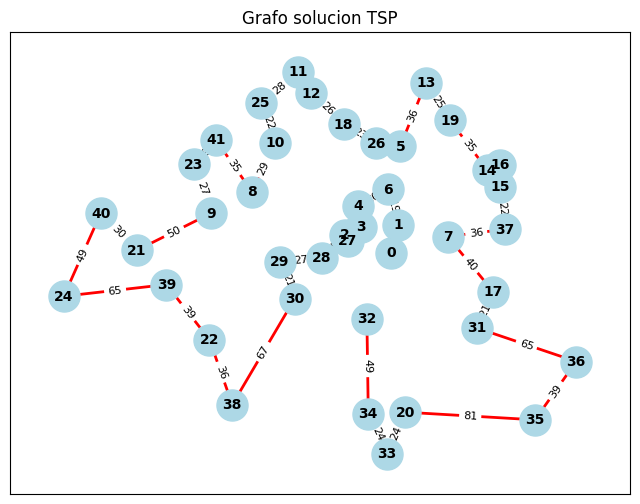

In [16]:
#Multiarranque + entornos variables: 5 arranques
sol_multi_entornos, distancias_multi_entornos = busqueda_local_multiarranque(problem, 5, busqueda_entornos_variables)

#Resumen de las mejoras de la busqueda local
#(la media de los arranques es lo que se obtiene, de media, con 1 sola ejecucion)
print()
print("RESUMEN BUSQUEDA LOCAL (distancia total)")
print("Busqueda local basica          - media de los 10 arranques :" , sum(distancias_multiarranque)/len(distancias_multiarranque))
print("Multiarranque                  - mejor de los 10 arranques :" , min(distancias_multiarranque))
print("Entornos variables             - media de los 5 arranques  :" , sum(distancias_multi_entornos)/len(distancias_multi_entornos))
print("Multiarranque + ent. variables - mejor de los 5 arranques  :" , min(distancias_multi_entornos))
print("Optimo conocido de swiss42 (TSPLIB)                        :" , 1273)

plot_tsp_solution(problem.edge_weights, sol_multi_entornos)

## Extra 2: Recocido simulado, mejora en la selección de vecinos

En la plantilla la vecina se elige intercambiando 2 nodos tomados 100% al azar. Se mejora en dos pasos:

1. **Cambio de movimiento**: en lugar de intercambiar 2 nodos se invierte un tramo del recorrido (2-opt de aristas). El intercambio cambia hasta 4 aristas del recorrido y la inversión solo 2, así que la vecina se parece más a la solución actual y es más fácil que sea una buena solución.
2. **Selección guiada por cercanía**: los extremos del tramo ya no se eligen los dos al azar. Se elige un nodo al azar y el otro se elige entre sus `K` nodos más cercanos, de forma que la inversión los deja contiguos en el recorrido. Así una de las dos aristas nuevas que crea la inversión es siempre corta y no se gastan iteraciones en vecinas que unen nodos muy alejados.

In [17]:
###############################################################################
# EXTRA 2 - SIMULATED ANNEALING: MEJORA EN LA SELECCION DE VECINOS
###############################################################################

#Mejora 1 - Cambio de movimiento:
#Generador de 1 solucion vecina por inversion de un tramo elegido 100% al azar (2-opt de aristas)
def genera_vecina_inversion_aleatorio(solucion):

  #Se eligen dos posiciones aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero con el tramo i..j recorrido al reves
  return solucion[:i] + solucion[i:j+1][::-1] + solucion[j+1:]


#Mejora 2 - Seleccion guiada por cercania:
#Para cada nodo guardamos la lista de sus K nodos mas cercanos (se calcula una sola vez)
K_CERCANOS = 5
CERCANOS = {}
for a in Nodos:
  CERCANOS[a] = sorted([b for b in Nodos if b != a], key=lambda b: distancia(a, b, problem))[:K_CERCANOS]

#Generador de 1 solucion vecina por inversion, pero eligiendo el tramo de forma guiada:
#un nodo al azar y uno de sus nodos cercanos, que quedan contiguos despues de invertir
def genera_vecina_guiada(solucion):
  while(1):
    #Posicion de un nodo elegido al azar ...
    i = random.randrange(1, len(solucion))

    #... y posicion de uno de sus K nodos mas cercanos
    j = solucion.index(random.choice(CERCANOS[solucion[i]]))

    i,j = sorted((i,j))

    #Si ya son contiguos en el recorrido no hay nada que mejorar: se eligen otros
    if j - i >= 2 and (i,j) != (0, len(solucion)-1):

      #Devuelve una nueva solución con el tramo i+1..j invertido: los dos nodos quedan contiguos
      #(la posicion 0 nunca se mueve, el recorrido sigue comenzando en el nodo 0)
      return solucion[:i+1] + solucion[i+1:j+1][::-1] + solucion[j+1:]

Para medir solo el efecto de la selección de vecinos se usa el mismo recocido simulado de la plantilla (misma temperatura inicial, mismo descenso de temperatura y misma función de probabilidad) y lo único que cambia es el generador de vecinas, que pasa a ser un parámetro. Como el resultado es aleatorio, cada generador se ejecuta varias veces y se compara la media.

RESUMEN RECOCIDO SIMULADO (distancia total en 20 ejecuciones)
Intercambio aleatorio (plantilla)  -> media: 2017.8  mejor: 1814  peor: 2358
Inversion aleatoria                -> media: 1560.95  mejor: 1444  peor: 1679
Inversion guiada por cercania      -> media: 1371.3  mejor: 1274  peor: 1545

La mejor solución encontrada con la seleccion guiada es [0, 1, 6, 4, 3, 27, 2, 28, 29, 30, 38, 22, 39, 21, 24, 40, 9, 23, 41, 8, 10, 25, 11, 12, 18, 26, 5, 13, 19, 14, 16, 15, 37, 7, 17, 31, 36, 35, 20, 33, 34, 32]
con una distancia total de 1274


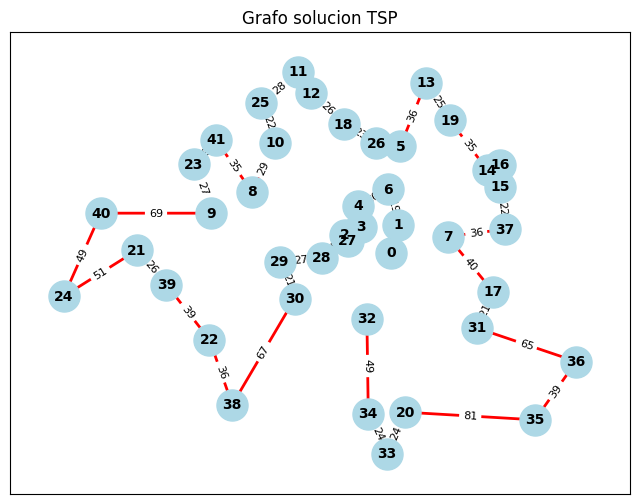

In [18]:
#Recocido simulado de la plantilla, pero recibiendo el generador de vecinas como parametro
#Devuelve la mejor solucion y su distancia
def recocido_simulado_vecinos(problem, TEMPERATURA, genera):
  #problem = datos del problema
  #T = Temperatura
  #genera = funcion que genera una solucion vecina

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo

  while TEMPERATURA > .0001:
    #Genera una solución vecina con el generador recibido
    vecina = genera(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  return mejor_solucion, mejor_distancia


#Comparativa: N_PRUEBAS ejecuciones del recocido con cada generador de vecinas
N_PRUEBAS = 20
generadores = [("Intercambio aleatorio (plantilla)", genera_vecina_aleatorio),
               ("Inversion aleatoria"              , genera_vecina_inversion_aleatorio),
               ("Inversion guiada por cercania"    , genera_vecina_guiada)]

mejor_sol_sa = []
mejor_distancia_sa = float('inf')

print("RESUMEN RECOCIDO SIMULADO (distancia total en", N_PRUEBAS, "ejecuciones)")
for nombre, genera in generadores:
  distancias = []
  for i in range(N_PRUEBAS):
    sol_sa, distancia_sa = recocido_simulado_vecinos(problem, 10000000, genera)
    distancias.append(distancia_sa)

    #Guardamos la mejor solucion del generador mejorado para dibujarla
    if genera == genera_vecina_guiada and distancia_sa < mejor_distancia_sa:
      mejor_sol_sa = sol_sa
      mejor_distancia_sa = distancia_sa

  print(nombre.ljust(34), "-> media:", sum(distancias)/N_PRUEBAS, " mejor:", min(distancias), " peor:", max(distancias))

print()
print("La mejor solución encontrada con la seleccion guiada es " , end="")
print(mejor_sol_sa)
print("con una distancia total de " , end="")
print(mejor_distancia_sa)

plot_tsp_solution(problem.edge_weights, mejor_sol_sa)